In [247]:
import numpy as np
import scipy
from netCDF4 import Dataset
from matplotlib import pyplot as plt
import xarray as xr
import matplotlib.colors as colors
import metpy
import cmaps
import matplotlib
from scipy import optimize

In [248]:
# Compute speeds for models with a pressure vertical coordinate
def p_coord_speeds(zTs, H, g, kappa):
    # zTs: Range of model top heights
    # H: Isothermal scale height

    roots = np.zeros_like(zTs)
    heights = np.zeros_like(zTs)
    speeds = np.zeros_like(zTs)

    # Positive value as a guess for root solving
    x0 = 0.5

    eps = 1e-8
    
    for i in np.arange(len(zTs)):
        zT = zTs[i]

        # Define the residual
        if zT < (8*H/3):
            def R_func(x):
                return np.tan(x) - 4*kappa*H*x/(zT*(1 - 2*kappa + (2*H*x/zT)**2))

            #x_root = scipy.optimize.fsolve(R_func, x0)
            
            x_root = scipy.optimize.root_scalar(R_func, bracket = [eps,np.pi/2-eps], method='brentq')
            x_root = x_root.root
            
            #x_root = scipy.optimize.brentq(R_func, 0.01, np.pi/2)
            
            # Back out the height
            h_star = 4*kappa*H/((2*H*x_root/zT)**2 + 1)
            
        else:
            def R_func(x):
                return np.tanh(x) - 4*kappa*H*x/(zT*(1 - 2*kappa - (2*H*x/zT)**2))
        
            # Compute the singularity point 
            x_up = zT * np.sqrt(1-2*kappa)/(2*H)
                
            #x_root = scipy.optimize.fsolve(R_func, x0)
            x_root = scipy.optimize.root_scalar(R_func, bracket = [1e-6, 0.99*x_up], method='brentq')
            x_root = x_root.root
            
            #x_root = scipy.optimize.brentq(R_func, 0.01, np.pi/2)
    
            # Back out the height
            h_star = 4*kappa*H/(1 - (2*H*x_root/zT)**2)

    

        # Comptue the speed
        roots[i] = x_root
        heights[i] = h_star
        speeds[i] = np.sqrt(g*h_star)


    return roots, heights, speeds

    
    

In [249]:
# Manually add the wavespeeds 

# Which test are we looking at??
test = 'p_pert'
#test = 'acid'

# Model top heights
zT_range_km = np.linspace(10, 100, 100)
zT_range_m = zT_range_km*1000
zT_vals = ([12.5, 25, 50, 100])

In [250]:
if test == 'p_pert':
    se_speeds = np.array([310, 315, 320, 325])
    fv3_speeds = np.array([305, 310, 324, 325])
    mpas_speeds = np.array([330,330,330,330])
elif test == 'acid':
    se_speeds = np.array([312, 317, 322, 327])
    fv3_speeds = np.array([310, 315, 320, 325])
    mpas_speeds = np.array([330,330,330,330])

In [251]:
# Theoretical Lamb wave speed with no model top dependence
gamma = 7./5.
R_d = 287.04
T0 = 275
lamb_speed = np.sqrt(gamma*R_d*T0)
lamb_speed_array = lamb_speed*np.ones(len(zT_range_m))

print(f'Expected Lamb wave speed is {lamb_speed}')

Expected Lamb wave speed is 332.4310454816156


8046.483180428134
21457.28848114169


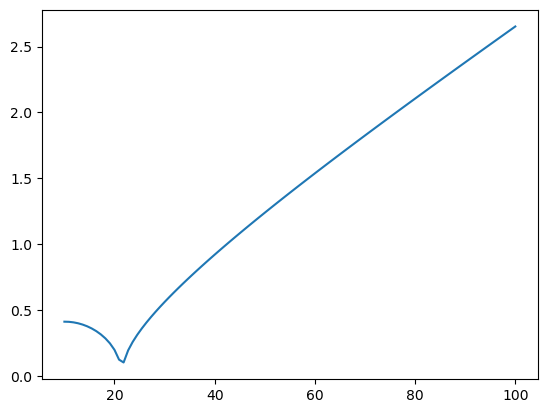

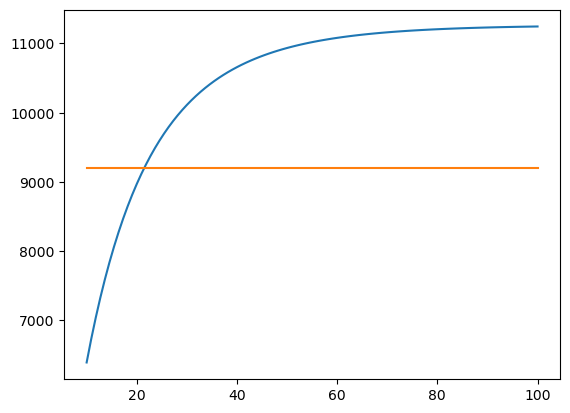

In [252]:
# Compute the expected speeds for SE and FV3.
Rd = 287.04
T0 = 275
g = 9.81
H = Rd*T0/g
print(H)
print(8*H/3)
kappa = 2./7.

roots, heights, lamb_speed_p_coord = p_coord_speeds(zT_range_m, H, g, kappa)

plt.figure()
plt.plot(zT_range_km, roots)

plt.figure()
plt.plot(zT_range_km, heights)
plt.plot(zT_range_km, np.ones(len(heights))*8*H/7)

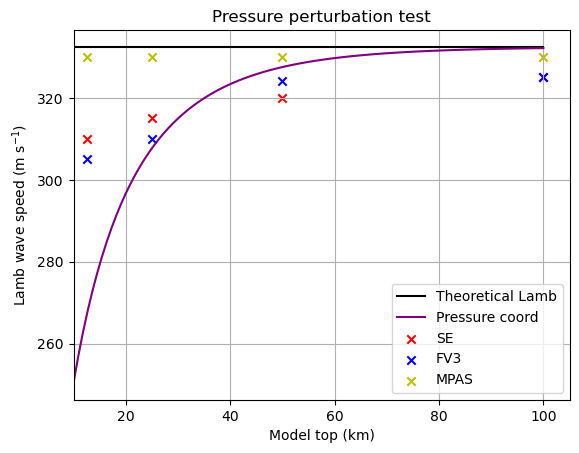

In [255]:
# Make the figure
plt.figure()
plt.plot(zT_range_km, lamb_speed_array, c='k', label='Theoretical Lamb')
plt.plot(zT_range_km, lamb_speed_p_coord, c='purple', label='Pressure coord')
#plt.plot(zT_range, lamb_speed*, c='k', label='Theoretical with mixed BCs')
plt.scatter(zT_vals, se_speeds, c = 'r', marker = 'x', label='SE')
plt.scatter(zT_vals, fv3_speeds, c = 'b', marker = 'x', label='FV3')
plt.scatter(zT_vals, mpas_speeds, c = 'y', marker = 'x', label='MPAS')

if test == 'p_pert':
    plt.title('Test case 1')
elif test == 'acid':
    plt.title('Test case 2')

plt.xlabel('Model top (km)')
plt.ylabel(r'Lamb wave speed (m s$^{-1}$)')
plt.xlim([10,105])
#plt.ylim([300,340])

plt.legend(loc='lower right')
plt.grid()

if test == 'p_pert':
    plt.title('Pressure perturbation test')
    plt.savefig(f'figures/p_pert_speeds_with_ztop.jpg', bbox_inches='tight')
elif test == 'acid':
    plt.title('Acid test')
    plt.savefig(f'figures/acid_speeds_with_ztop.jpg', bbox_inches='tight')

plt.show()


In [254]:
# What about comparing the fields??


fig, axes = plt.subplots(1,3, figsize=(10,5), sharey = True)
ax1, ax2, ax3 = axes

ax1.plot(


_IncompleteInputError: incomplete input (732973997.py, line 7)